# Методы кластеризации

Наиболее популярные методы кластеризации в  Sklearn реализованы в классе Cluster

Существует множество различных типов кластеризации, которые можно разделить по следующим критериям:

**По способу формирования кластеров:**

* Разделительные (partitioning) — разбивают данные на заданное число кластеров, минимизируя расстояние внутри кластера и максимизируя расстояние между кластерами (например, K-means).

* Основанные на плотности (density-based) — группируют точки, которые находятся в областях с высокой плотностью и отделяют их от областей с низкой плотностью (например, DBSCAN).

* Основанные на сетке (grid-based) — разбивают пространство на ячейки сетки и анализируют плотность данных в каждой ячейке (например, STING).

* Основанные на модели (model-based) — предполагают, что данные порождены некоторой статистической моделью и пытаются подобрать параметры этой модели (например, смеси Гауссианов).

* Основанные на графах (graph-based) — используют графовое представление данных и разбивают его на подграфы, соответствующие кластерам (например, спектральная кластеризация).

* Основанные на подпространствах (subspace-based) — ищут кластеры в подпространствах признаков, а не во всём пространстве (например, CLIQUE).

* Основанные на ансамбле (ensemble-based) — комбинируют результаты различных алгоритмов кластеризации, чтобы получить более стабильное и надёжное разбиение (например, CSPA).

**По степени вложенности кластеров:**

* Плоские (flat) — разбивают данные на один уровень кластеров, не учитывая их иерархию (например, K-means).

* Иерархические (hierarchical) — разбивают данные на несколько уровней кластеров, учитывая их иерархию. Существуют два основных подхода к иерархической кластеризации: агломеративный (начинается с того, что каждый объект является отдельным кластером, а затем постепенно наиболее близкие кластеры объединяются в более крупные) и дивизивный (начинается с того, что все объекты составляют один кластер, а затем постепенно разделяются на более мелкие кластеры).

**По степени пересечения кластеров:**

* Четкие (Исключающие) (exclusive) — каждый объект принадлежит только одному кластеру (например, K-means).

* Перекрывающие (overlapping) — каждый объект может принадлежать нескольким кластерам (например, MCOKE).

* Нечёткие (fuzzy) — каждый объект принадлежит каждому кластеру с некоторой степенью принадлежности (например, fuzzy K-means).



**Текст:**

*Этот пример демонстрирует характеристики различных алгоритмов кластеризации на наборах данных в 2D. Конечно, некоторые из них более чувствительны к значениям параметров, чем другие, поэтому нужно опять же играть с ними. Важно также помнить, что если алгоритм использует метрику на множестве объектов, то значения всех признаков желательно масштабировать. Но опять же лучше пробовать и так, и так.*

*Последний набор данных является примером «патовой» ситуации для кластеризации: данные однородны, и кластеризация здесь бессмысленна.*

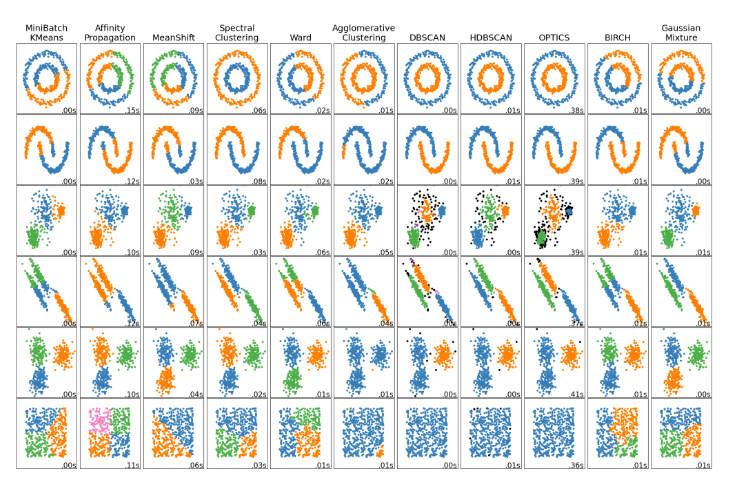

Как и у большинства алгоритмов из библиотеки sklearn, у них есть есть методы fit и predict

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
X = np.array([[1, 2], [1, 4], [1, 0],
              [10, 2], [10, 4], [10, 0]])
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto")
kmeans.fit(X)
kmeans.labels_
kmeans.predict([[0, 0], [12, 3]])
kmeans.cluster_centers_

array([[10.,  2.],
       [ 1.,  2.]])

# K-Means

Первым алгоритмом, с которым вы познакомились на лекции, был метод k-средних. Он ищет k скрытых кластеров, каждый из которых характеризуется центроидом или средним.


**Преимущества и недостатки K-Means**

Преимущества:

* прост в реализации и понимании;

* наличие большого числа модификаций;

* высокая скорость работы и точность на данных сферической формы.

Недостатки:

* низкая точность на данных с несферической формой кластеров;

* чувствительность к начальным значениям центроидов и выбросам;

* необходимость заранее устанавливать число кластеров, что может быть сложно или не оптимально.

Пример визуализации алгоритма: https://www.naftaliharris.com/blog/visualizing-k-means-clustering/

## Применение кластеризации для сжатия изображения

На прошлом уроке мы применяли с вами кластеризацию для сегментации черно-белого изображения. Если же мы применим ее таким же образом к цветному изображению, то сможем его сжать.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from sklearn.cluster import KMeans
from skimage import io
from matplotlib.patches import Rectangle

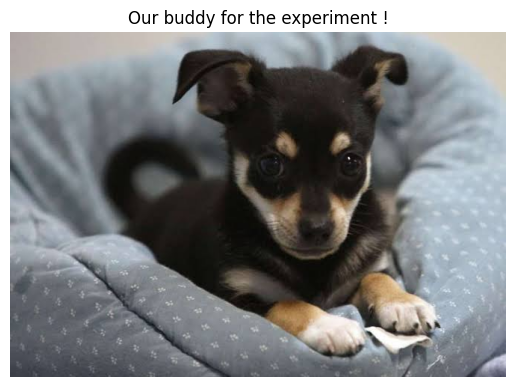

In [2]:
url = 'https://encrypted-tbn0.gstatic.com/images?q=tbn%3AANd9GcTzLzdD4MoAPP3I_JjrxndAqKg1zXtEnaODwsHbH6il9BL3Qt61'
img_original = io.imread(url)
plt.axis('off')
plt.imshow(img_original)
plt.title('Our buddy for the experiment !')
plt.show()

### Задание

**Реализуйте метод compress_image_kmeans для сжатия изображения с помощью метода кластеризации KMeans.**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

def compress_image_kmeans(image, n_colors):
    """
    Сжимает изображение, уменьшая количество цветов до n_colors

    Parameters:
    image: исходное изображение
    n_colors: желаемое количество цветов

    Returns:
    compressed_image: сжатое изображение
    """

    # Получаем размеры изображения
    ... # TODO

    # Преобразуем изображение в массив пикселей (каждая строка - пиксель с RGB значениями)
    ... # TODO

    # Применяем K-Means кластеризацию по цветам пикселей
    ... # TODO

    # Получаем центры кластеров (новые цвета)
    ... # TODO

    # Создаем новое изображение, заменяя каждый пиксель на цвет его кластера
    ... # TODO
    compressed_image = image # Приводим одномерный массив к нужному размеру матрицы

    return compressed_image

Если код успешно написан, то вы получите такие изображения:

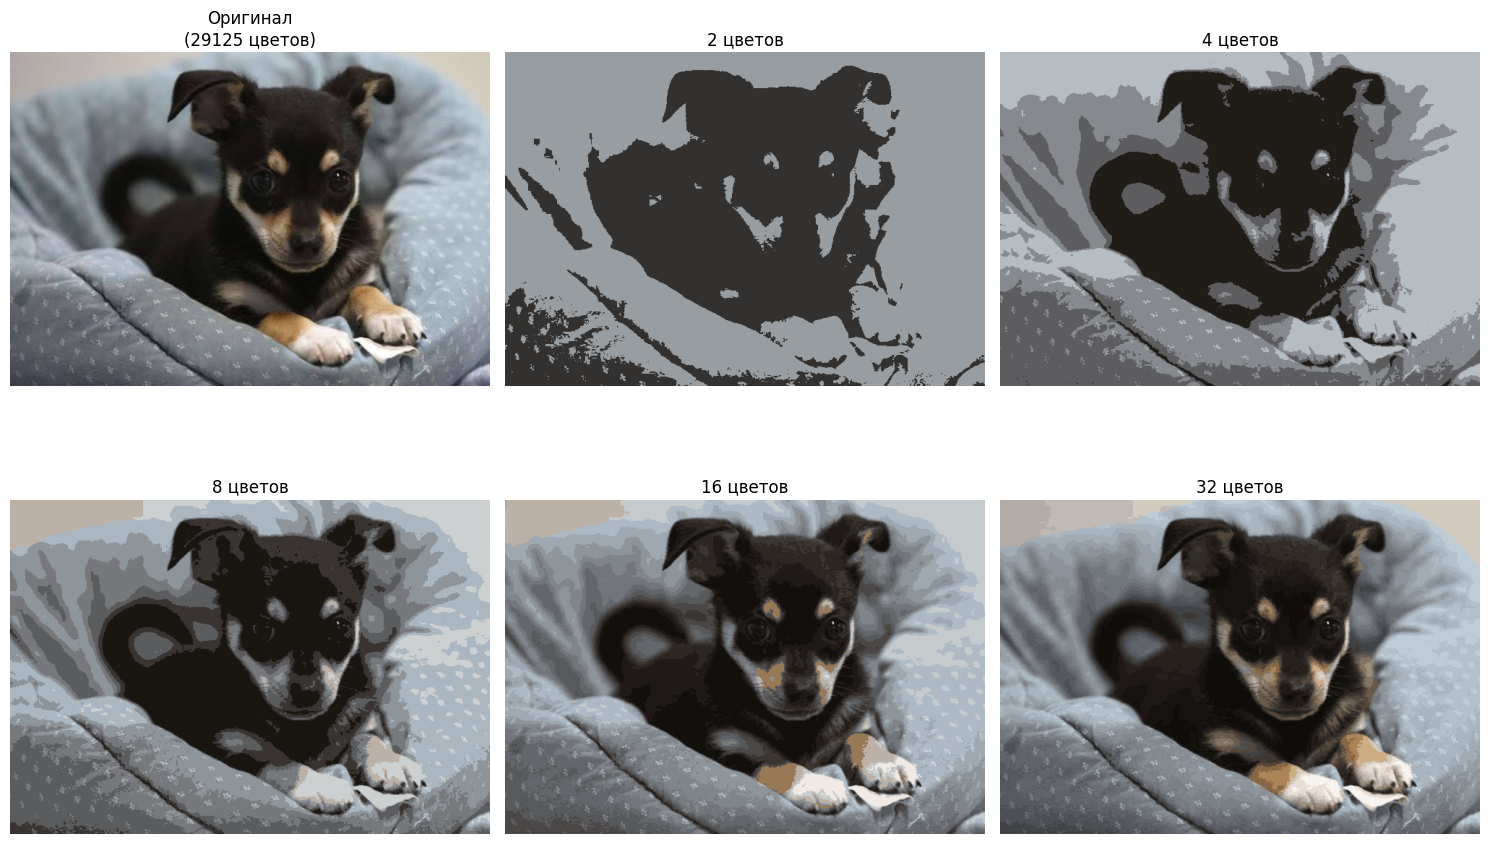

In [194]:
# Визуализация результатов для разного количества цветов
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
colors_to_try = [2, 4, 8, 16, 32]

# Оригинальное изображение для сравнения
axes[0, 0].imshow(img_original)
axes[0, 0].set_title(f'Оригинал\n({len(np.unique(img_original.reshape(-1, 3), axis=0))} цветов)')
axes[0, 0].axis('off')

# Сжимаем и отображаем изображения с разным количеством цветов
for i, n_colors in enumerate(colors_to_try):
    row = (i + 1) // 3
    col = (i + 1) % 3

    compressed_img = compress_image_kmeans(img_original, n_colors)

    axes[row, col].imshow(compressed_img)
    axes[row, col].set_title(f'{n_colors} цветов')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Иерархическая кластеризация

Иерархическая кластеризация подразумевает создание кластеров, которые имеют предопределенный порядок сверху вниз. Например, все файлы и папки на жестком диске организованы в иерархию. Существует два типа иерархической кластеризации: дивизивная и агломеративная.

**Вопрос по лекции: Чем они отличаются?**

### Основные разновидности дивизивных методов:

* **DIANA (DIvisive ANAlysis)** — на каждом шаге находит объект, наиболее отличающийся от остальных в кластере, и создает новый кластер, начиная с этого объекта.
* **Бисекционный K-means** — рекурсивно применяет алгоритм K-means с K=2 к каждому кластеру.
* **Монотетические методы** — разделяют кластеры на основе значения одного признака.
* **Политетические методы** — используют несколько признаков одновременно для разделения кластеров.

**BisectingKMeans**(n_clusters=8, *, init='random', n_init=1, random_state=None, max_iter=300, verbose=0, tol=0.0001, copy_x=True, algorithm='lloyd', bisecting_strategy='biggest_inertia')

Параметры:
* n_clusters: Желаемое количество кластеров. Если None, алгоритм будет продолжать объединение кластеров, пока не останется один кластер.
* biggest_inertia: Определяет, какой кластер будет выбран для разделения на очередном шаге:

    * "biggest_inertia" означает, что выбирается кластер с наибольшей суммой квадратов расстояний от точек до центроида. Использется, когда важнее всего минимизировать разброс внутри кластеров и получить более "чистые" группы. Этот подход сосредоточен на точность, но может быть дорогостоящей с точки зрения времени выполнения (особенно для большого количества точек данных).

    * "largest_cluster" означает, что выбирается кластер с наибольшим количеством точек. Используется, когда важно получить кластеры примерно одинакового размера. Это должно работать быстрее и может давать похожие результаты в большинстве случаев.

### Основные разновидности агломеративных методов на основе матрицы связей или расстояний:

Перед выполнением любой кластеризации необходимо определить матрицу близости, содержащую расстояние между каждой точкой с помощью функции расстояния. Затем матрица обновляется для отображения расстояния между каждым кластером. Следующие четыре метода различаются по способу измерения расстояния между каждым кластером:

**Одиночная связь (Single linkage)**<br>
**Полная связь (Complete linkage)**<br>
**Средняя связь (Average linkage)**<br>
**Метод Варда (Ward's method)**<br>

**Вопрос по лекции: Чем они отличаются между собой? Соотнесите каждую связь со своим изображением**

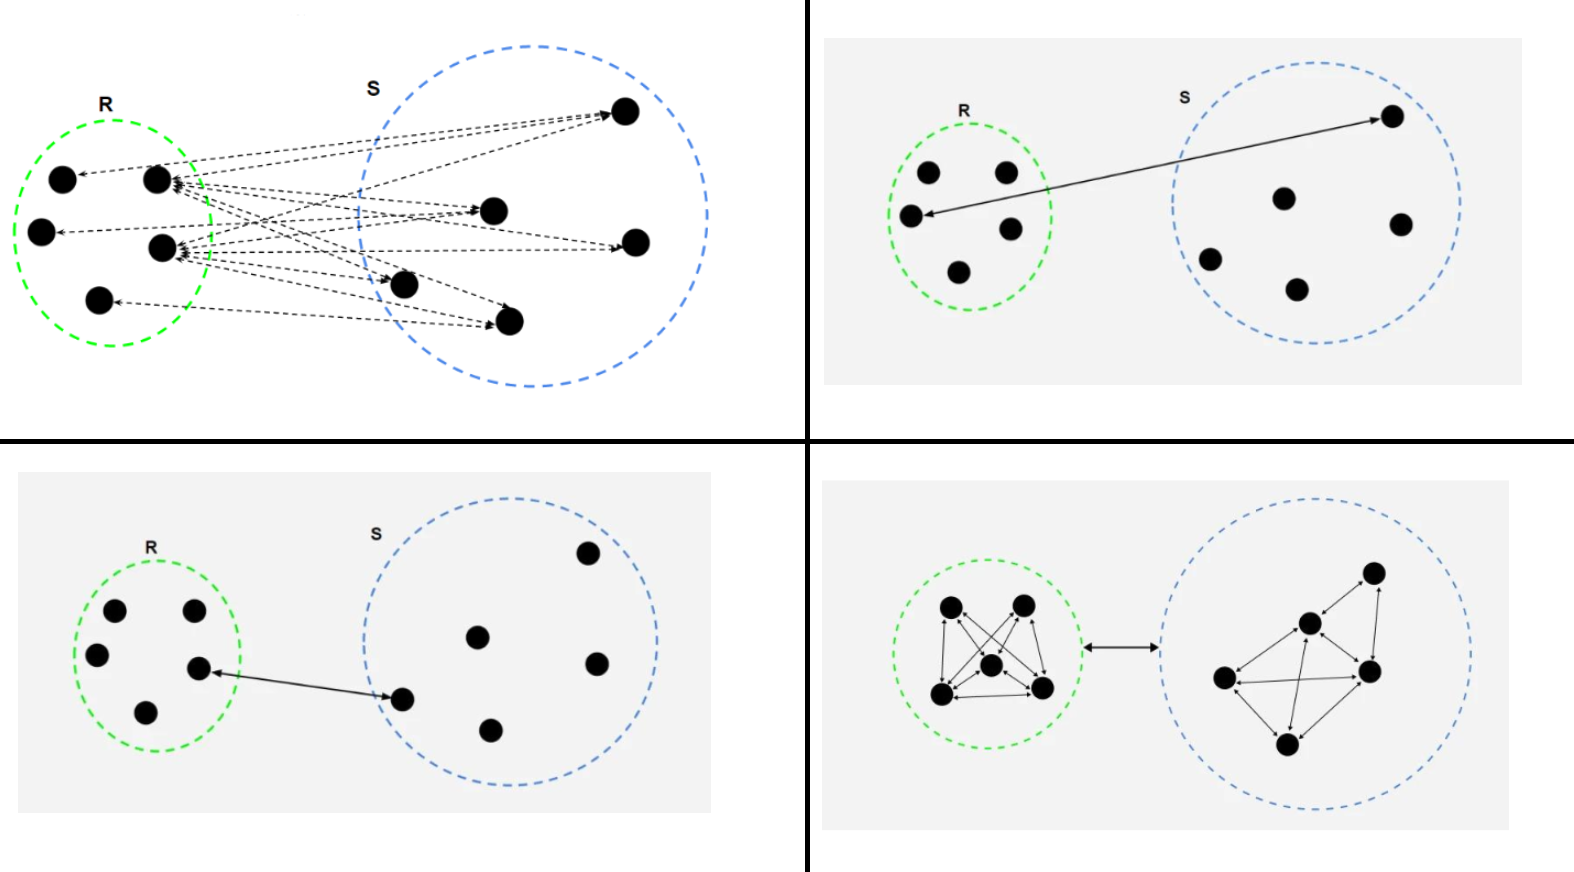

### Модель

**AgglomerativeClustering**(n_clusters=2, *, metric='euclidean', memory=None, connectivity=None, compute_full_tree='auto', linkage='ward', distance_threshold=None, compute_distances=False)

Параметры:
* n_clusters: Желаемое количество кластеров. Если None, алгоритм будет продолжать объединение кластеров, пока не останется один кластер.
* linkage: Критерий связи, определяющий, как вычисляется расстояние между кластерами.
    * "ward": Минимизирует дисперсию внутри кластеров.
    * "complete": Максимальное расстояние между точками в двух кластерах.
    * "average": Среднее расстояние между точками в двух кластерах.
    * "single": Минимальное расстояние между точками в двух кластерах.
* connectivity: Матрица связности, ограничивающая объединение кластеров.
* compute_full_tree: Если True, строит полное дерево кластеризации.
* distance_threshold: Порог для остановки объединения кластеров.
* compute_distances: Вычисляет расстояния между кластерами, если True.

### Dendograms

[Dendograms](https://en.wikipedia.org/wiki/Dendrogram) — это древовидные диаграммы, часто используемые для иллюстрации расположения кластеров, полученных иерархическим кластерированием. Клады располагаются в соответствии с тем, насколько они похожи (или непохожи). Клады, которые близки к одинаковой высоте, похожи друг на друга; клады с разной высотой — непохожи — чем больше разница в высоте, тем больше несходство.

Ниже показан пример с использованием известного набора данных Iris.

<img src=https://upload.wikimedia.org/wikipedia/commons/1/12/Iris_dendrogram.png height='400px' width = '400px'>

**AgglomerativeClustering** выдает уже готовые кластеры. Если необходимо вывести дендрограмму, то необходимо воспользоваться **linkage**. Но в нем нельзя установить количество кластеров, так как он строит именно иерархию, а не плоскую кластеризацию. Он вычисляет матрицу связей (*linkage matrix*), на основе которой можно построить дендрограмму и уже потом, глядя на нее, принять решение о необходимом количестве кластеров или пороге отсечения.

Если же изначально нужно и фиксированное число кластеров, и дендрограмма, то правильный путь — сначала использовать **linkage** для получения матрицы связей, а затем применить **fcluster**. Параметр criterion='maxclust' в fcluster как раз позволяет указать желаемое количество кластеров, используя результаты иерархической кластеризации, полученные из linkage. Таким образом, вы получаете и дендрограмму (из матрицы связей), и плоское разбиение на заданное число кластеров (из fcluster).

<br></br>



**linkage**(X, method='single', metric='euclidean')

Параметры:
* X: Данные.
* method: Критерий связи, определяющий, как вычисляется расстояние между кластерами.
    * "ward": Минимизирует дисперсию внутри кластеров.
    * "complete": Максимальное расстояние между точками в двух кластерах.
    * "average": Среднее расстояние между точками в двух кластерах.
    * "single": Минимальное расстояние между точками в двух кластерах.
* metric: Метрика расстояния.

<br></br>

**fcluster**(Z, t, criterion='inconsistent')

Параметры:
* Z: Матрица связей (linkage matrix).
* t: Пороговое значение для формирования кластера / количество кластеров.
* criterion: Критерий для формирования плоских кластеров. Если необходимо настроить количество кластеров, то выберите "maxclust".


## Пример работы (Код)

Набор данных со 101 видом животных, 17 признаками и 7 классами (млекопитающие, птицы, рептилии, рыбы, амфибии, беспозвоночные, насекомые).

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [173]:
class_df = pd.read_csv('class.csv')
zoo_df = pd.read_csv('zoo.csv')

### Подготовка данных

In [174]:
import pandas as pd
import numpy as np

Zoo = (zoo_df
    .drop(columns=['catsize', 'domestic'], errors='ignore')
    .assign(
        aquatic=lambda df: np.where(df['animal_name'] == 'clam', 1, df['aquatic']), # Моллюска должен быть водным
        breathes=lambda df: np.where(df['animal_name'] == 'seasnake', 1, df['breathes']), # Змея должна дышать
        venomous=lambda df: np.where(df['animal_name'] == 'platypus', 1, df['venomous']), # Утконос ядовит
        legs=lambda df: np.where(df['animal_name'] == 'seal', 4, df['legs']), # Устанавливает legs=4 для тюленя "seal" (вместо ласт)
        type=lambda df: np.select(
            [df['class_type'] == i for i in range(1, 8)], # Добавление текстовых названий классов для удобства
            ['Mammal', 'Bird', 'Reptile', 'Fish', 'Amphibian', 'Bug', 'Invertebrate'],
            default=df['type'] if 'type' in df.columns else None
        )
    )
    .assign(
        type=lambda df: np.select(
            [
                df['animal_name'].isin(['flea', 'gnat', 'honeybee', 'housefly', 'ladybird',
                                      'moth', 'termite', 'wasp', 'scorpion', 'slug', 'worm']),
                df['animal_name'].isin(['clam', 'crab', 'crayfish', 'lobster',
                                       'octopus', 'seawasp', 'starfish'])
            ],
            ['terrestrial_invertebrate', 'aquatic_invertebrate'], # Наземные беспозвоночные (насекомые) и морские
            default=df['type']
        )
    )
    .assign(
        class_type=lambda df: np.select(
            [df['type'] == 'terrestrial_invertebrate', df['type'] == 'aquatic_invertebrate'],
            [6, 7],
            default=df['class_type'] # Обновление числовых кодов классов
        ),
        tail=lambda df: np.select(
            [
                df['type'] == 'Fish',
                df['animal_name'].isin(['Aardvaark', 'bear', 'seal'])
            ],
            [0, 1],
            default=df['tail'] # Исправление переменной tail (хвост)
        ),
        caudal_fin=lambda df: np.where(df['type'] == 'Fish', 1, 0), # Создание caudal_fin (хвостовой плавник)
        legs=lambda df: np.select(
            [
                df['animal_name'].isin(['wallaby', 'sealion']),
                df['animal_name'].isin(['crab', 'crayfish', 'lobster'])
            ],
            [4, 10],
            default=df['legs'] # Исправление количества ног
        )
    )
)

In [123]:
class_df

,Class_Number,Number_Of_Animal_Species_In_Class,Class_Type,Animal_Names
0,1,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,..."
1,2,20,Bird,"chicken, crow, dove, duck, flamingo, gull, haw..."
2,3,5,Reptile,"pitviper, seasnake, slowworm, tortoise, tuatara"
3,4,13,Fish,"bass, carp, catfish, chub, dogfish, haddock, h..."
4,5,4,Amphibian,"frog, frog, newt, toad"
5,6,8,Bug,"flea, gnat, honeybee, housefly, ladybird, moth..."
6,7,10,Invertebrate,"clam, crab, crayfish, lobster, octopus, scorpi..."


In [175]:
Zoo.head(5)

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,class_type,type,caudal_fin
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,1,Mammal,0
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,Mammal,0
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,0,4,Fish,1
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,1,1,Mammal,0
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,1,Mammal,0


In [114]:
#Zoo = zoo_df # метрика силуэта 0.489 / точность 0.871

In [176]:
# Подготовка данных (исключаем текстовые и целевые колонки)
feature_cols = ['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic',
                'predator', 'toothed', 'backbone', 'breathes', 'venomous',
                'fins', 'legs', 'tail', 'caudal_fin']
X = Zoo[feature_cols].values

# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Получение истинных классов
true_labels = Zoo['class_type'].values
animal_names = Zoo['animal_name'].values if 'animal_name' in Zoo.columns else None

### Дендрограмма

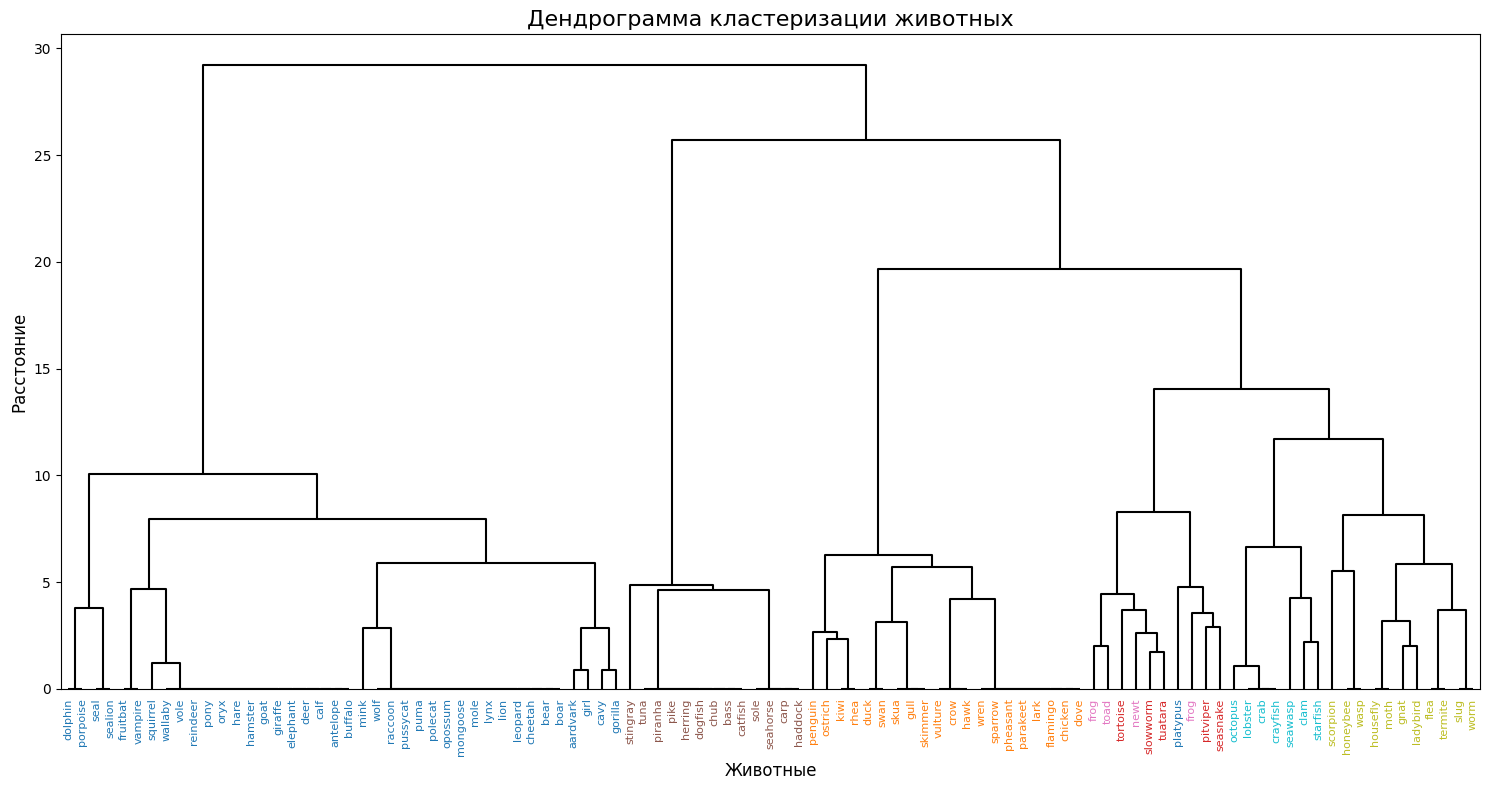

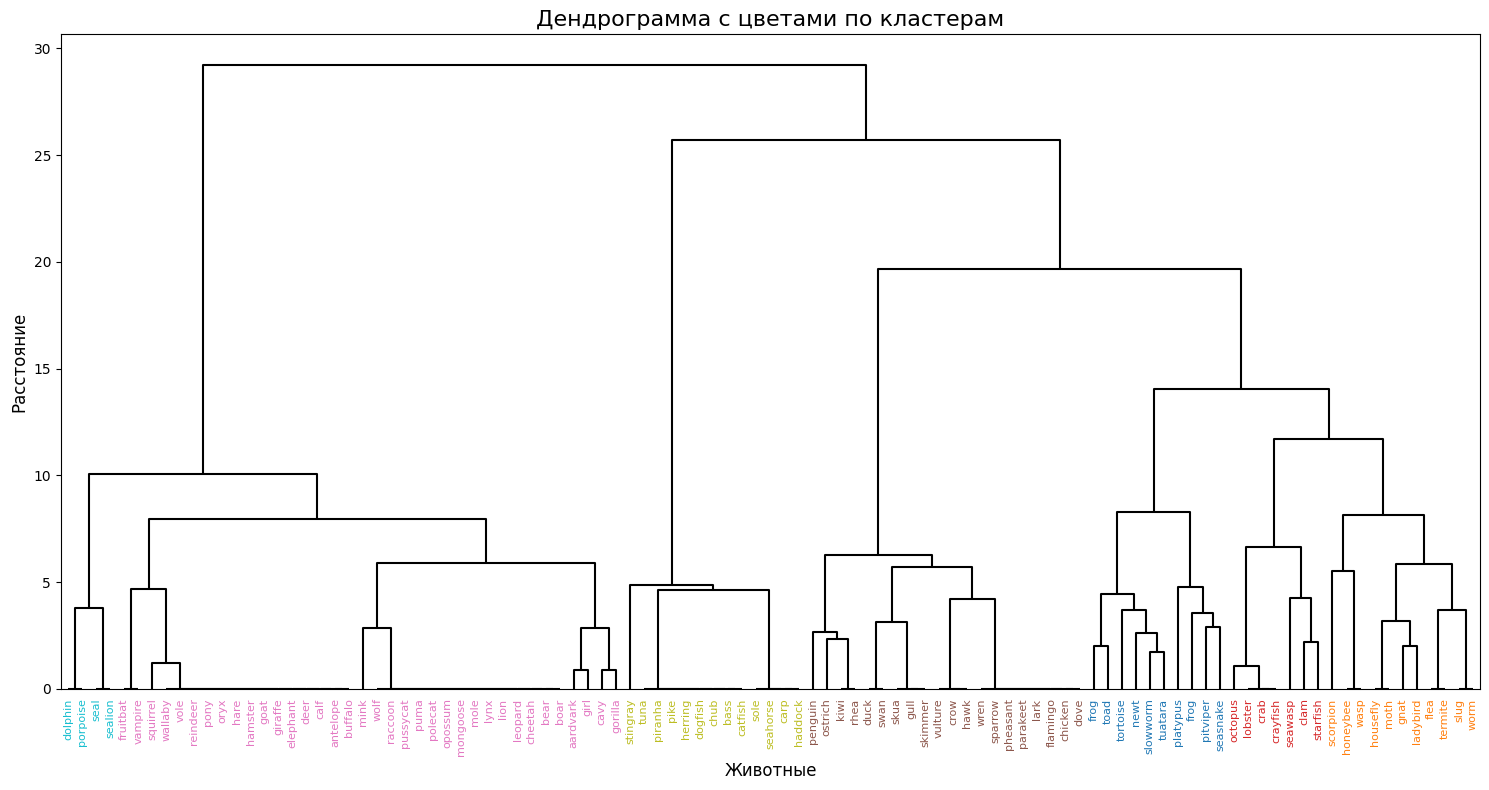

In [7]:
# Построение linkage матрицы для дендрограммы
linkage_matrix = linkage(X_scaled, method='ward')

# Создание цветовой карты для классов
unique_classes = np.unique(true_labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_classes)))
color_map = {cls: colors[i] for i, cls in enumerate(unique_classes)}

# Построение дендрограммы с получением информации о порядке листьев
plt.figure(figsize=(15, 8))
dendro = dendrogram(linkage_matrix,
                    labels=animal_names,
                    leaf_rotation=90,
                    leaf_font_size=8,
                    link_color_func=lambda k: 'black')

# Получаем порядок листьев из дендрограммы
leaf_order = dendro['leaves']
# Получаем метки в порядке отображения на дендрограмме
leaf_labels = dendro['ivl']

# Создаем список цветов в порядке отображения на дендрограмме
leaf_colors_ordered = []
for idx in leaf_order:
    # Получаем класс для данного индекса и соответствующий цвет
    leaf_class = true_labels[idx]
    leaf_colors_ordered.append(color_map[leaf_class])

# Применяем цвета к меткам в правильном порядке
ax = plt.gca()
xlbls = ax.get_xmajorticklabels()
for i, lbl in enumerate(xlbls):
    if i < len(leaf_colors_ordered):
        lbl.set_color(leaf_colors_ordered[i])

plt.title('Дендрограмма кластеризации животных', fontsize=16)
plt.xlabel('Животные', fontsize=12)
plt.ylabel('Расстояние', fontsize=12)
plt.tight_layout()
plt.show()

# Выполнение агломеративной кластеризации
n_clusters = len(unique_classes)  # или задайте своё число кластеров
clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
cluster_labels = clustering.fit_predict(X_scaled)

# Для проверки: можно также построить дендрограмму с цветами по кластерам
plt.figure(figsize=(15, 8))
# Создаем цветовую карту для кластеров
unique_clusters = np.unique(cluster_labels)
cluster_colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
cluster_color_map = {cls: cluster_colors[i] for i, cls in enumerate(unique_clusters)}

# Получаем цвета для кластеров в порядке листьев
cluster_colors_ordered = [cluster_color_map[cluster_labels[idx]] for idx in leaf_order]

# Строим дендрограмму
dendro = dendrogram(linkage_matrix,
                    labels=animal_names,
                    leaf_rotation=90,
                    leaf_font_size=8,
                    link_color_func=lambda k: 'black')

# Раскрашиваем метки по кластерам
ax = plt.gca()
xlbls = ax.get_xmajorticklabels()
for i, lbl in enumerate(xlbls):
    if i < len(cluster_colors_ordered):
        lbl.set_color(cluster_colors_ordered[i])

plt.title('Дендрограмма с цветами по кластерам', fontsize=16)
plt.xlabel('Животные', fontsize=12)
plt.ylabel('Расстояние', fontsize=12)
plt.tight_layout()
plt.show()

**Вопрос: Как можно улучшить кластеризацию в этом случае?**

```
feature_cols = ['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic',
                'predator', 'toothed', 'backbone', 'breathes', 'venomous',
                'fins', 'legs', 'tail', 'caudal_fin']

feature_cols = ["волосы", "перья", "яйца", "молоко", "воздушные", "водные",
                "хищные", "зубастые", "позвоночник", "дышащие (не жабры)", "ядовитые",
                "плавники", "ноги", "хвост", "хвостовой плавник']
```

In [191]:
# Создаем DataFrame с признаками и добавляем целевую переменную
df = Zoo[feature_cols + ['type', 'animal_name']].copy()

# Получаем уникальные классы
unique_classes = df['type'].unique()
unique_classes.sort()

# Создаем перевернутую таблицу (классы как строки, признаки как столбцы)
print("Уникальные значения признаков по каждому классу (перевернутая таблица):")
print("="*180)

# Создаем список для данных
transposed_data = []

# Для каждого класса собираем уникальные значения по всем признакам
for class_val in unique_classes:
    row = {'Class': f'{class_val}'}
    class_data = df[df['type'] == class_val]

    for feature in feature_cols:
        unique_vals = class_data[feature].unique()
        row[feature] = unique_vals

    transposed_data.append(row)

# Создаем DataFrame
transposed_df = pd.DataFrame(transposed_data)
print(transposed_df.to_string(index=False))

Уникальные значения признаков по каждому классу (перевернутая таблица):
                   Class   hair feathers   eggs milk airborne aquatic predator toothed backbone breathes venomous   fins          legs   tail caudal_fin
               Amphibian    [0]      [0]    [1]  [0]      [0]     [1]   [1, 0]     [1]      [1]      [1]   [0, 1]    [0]           [4] [0, 1]        [0]
                    Bird    [0]      [1]    [1]  [0]   [1, 0]  [0, 1]   [0, 1]     [0]      [1]      [1]      [0]    [0]           [2]    [1]        [0]
                    Fish    [0]      [0]    [1]  [0]      [0]     [1]   [1, 0]     [1]      [1]      [0]   [0, 1]    [1]           [0]    [0]        [1]
                  Mammal [1, 0]      [0] [0, 1]  [1]   [0, 1]  [0, 1]   [1, 0]  [1, 0]      [1]      [1]   [0, 1] [0, 1]     [4, 0, 2] [0, 1]        [0]
                 Reptile    [0]      [0] [1, 0]  [0]      [0]  [0, 1]   [1, 0]  [1, 0]      [1]      [1]   [1, 0]    [0]        [0, 4]    [1]        [0]
    aquati

In [192]:
df[(df['type'] == 'terrestrial_invertebrate') & (df['hair'] == 1)]

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,caudal_fin,type,animal_name
39,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,terrestrial_invertebrate,honeybee
40,1,0,1,0,1,0,0,0,0,1,0,0,6,0,0,terrestrial_invertebrate,housefly
51,1,0,1,0,1,0,0,0,0,1,0,0,6,0,0,terrestrial_invertebrate,moth
97,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,terrestrial_invertebrate,wasp


In [8]:
# Выполнение агломеративной кластеризации
n_clusters = len(unique_classes)  # или задайте своё число кластеров
clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
cluster_labels = clustering.fit_predict(X_scaled)

### TSNE Визуализация

Снижение размерности с помощью t-SNE (t-Distributed Stochastic Neighbor Embedding) для визуализации многомерных данных в низкоразмерном пространстве (обычно 2D или 3D).

Оси t-SNE - это не конкретные признаки, а математическая абстракция, которая:

* Располагает похожие объекты близко
* Располагает разные объекты далеко
* Не имеет физического смысла
* Не сохраняет масштаб
* Сохраняет только локальную структуру

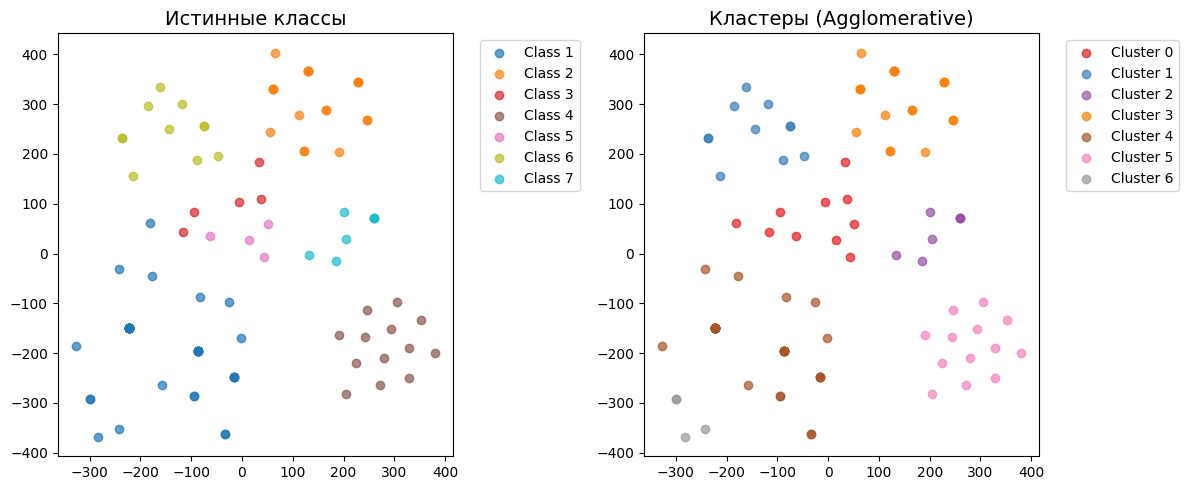

In [9]:
# Визуализация результатов (t-SNE для 2D проекции)
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for cls in unique_classes:
    mask = true_labels == cls
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=[color_map[cls]], label=f'Class {cls}', alpha=0.7)
plt.title('Истинные классы', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(1, 2, 2)
unique_clusters = np.unique(cluster_labels)
cluster_colors = plt.cm.Set1(np.linspace(0, 1, len(unique_clusters)))
for i, cluster in enumerate(unique_clusters):
    mask = cluster_labels == cluster
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=[cluster_colors[i]], label=f'Cluster {cluster}', alpha=0.7)
plt.title('Кластеры (Agglomerative)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Оценка качества

Silhouette Score: 0.529
Accuracy (Mode mapping): 0.950

Confusion Matrix:
[[40  0  1  0  0  0  0]
 [ 0 20  0  0  0  0  0]
 [ 0  0  5  0  0  0  0]
 [ 0  0  0 13  0  0  0]
 [ 0  0  4  0  0  0  0]
 [ 0  0  0  0  0 11  0]
 [ 0  0  0  0  0  0  7]]

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.98      0.99        41
           2       1.00      1.00      1.00        20
           3       0.50      1.00      0.67         5
           4       1.00      1.00      1.00        13
           5       0.00      0.00      0.00         4
           6       1.00      1.00      1.00        11
           7       1.00      1.00      1.00         7

    accuracy                           0.95       101
   macro avg       0.79      0.85      0.81       101
weighted avg       0.94      0.95      0.94       101



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


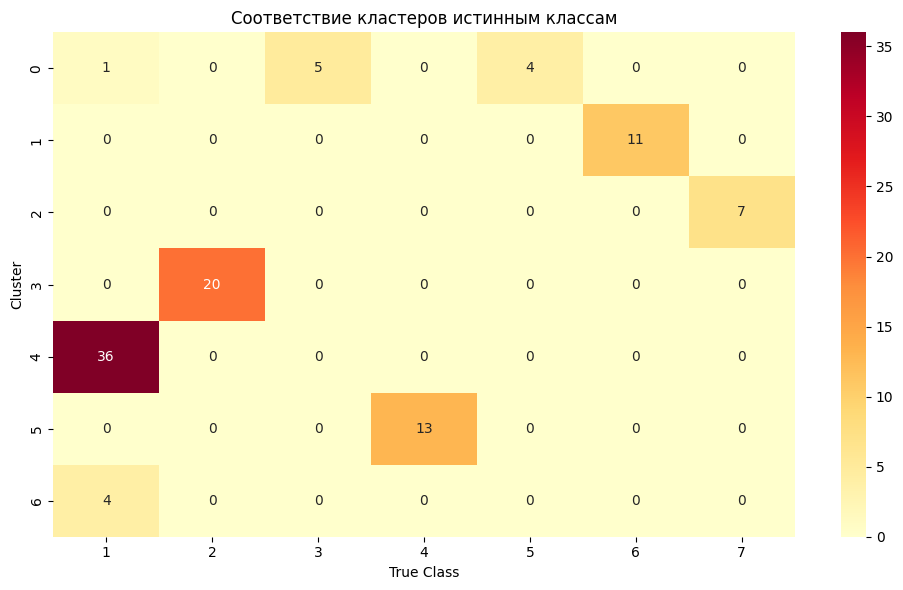


СВОДНАЯ ТАБЛИЦА МЕТРИК
Silhouette Score: 0.529 (чем ближе к 1, тем лучше)
Accuracy (Mode mapping): 0.950
Количество кластеров: 7
Количество классов: 7


In [89]:
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1. Метрика Silhouette для оценки качества кластеризации
silhouette_avg = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.3f}")

# 2. Связывание кластеров с классами: найти наиболее частый класс в каждом кластере
cluster_to_class = {}
for cluster in np.unique(cluster_labels):
    mask = cluster_labels == cluster
    # Самый частый класс в этом кластере
    most_common_class = np.bincount(true_labels[mask]).argmax()
    cluster_to_class[cluster] = most_common_class

# Маппинг предсказаний
mapped_predictions = np.array([cluster_to_class[cluster] for cluster in cluster_labels])

# Accuracy на основе маппинга
mapping_accuracy = accuracy_score(true_labels, mapped_predictions)
print(f"Accuracy (Mode mapping): {mapping_accuracy:.3f}")

# 3. Дополнительные метрики
from sklearn.metrics import confusion_matrix, classification_report

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, mapped_predictions))

print("\nClassification Report:")
print(classification_report(true_labels, mapped_predictions))

# 4. Визуализация соответствия
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Матрица соответствия кластеров и классов
cluster_class_matrix = pd.crosstab(
    pd.Series(cluster_labels, name='Cluster'),
    pd.Series(true_labels, name='True Class')
)

sns.heatmap(cluster_class_matrix, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Соответствие кластеров истинным классам')
plt.tight_layout()
plt.show()

# 5. Сводная таблица результатов
print("\n" + "="*50)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК")
print("="*50)
print(f"Silhouette Score: {silhouette_avg:.3f} (чем ближе к 1, тем лучше)")
print(f"Accuracy (Mode mapping): {mapping_accuracy:.3f}")
print(f"Количество кластеров: {len(np.unique(cluster_labels))}")
print(f"Количество классов: {len(np.unique(true_labels))}")

# Графовая кластеризация

**Вопрос: Какие алгоритмы для построения остовных деревьев вы помните?**

## MST подход

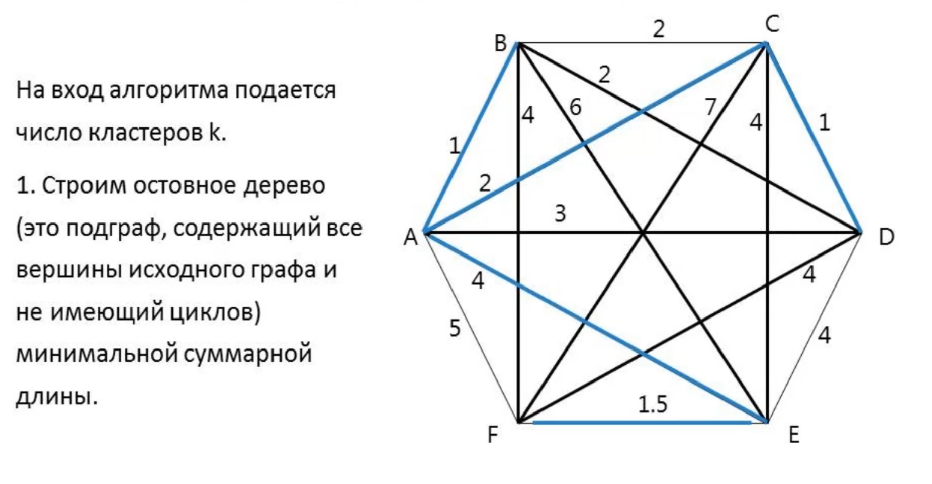

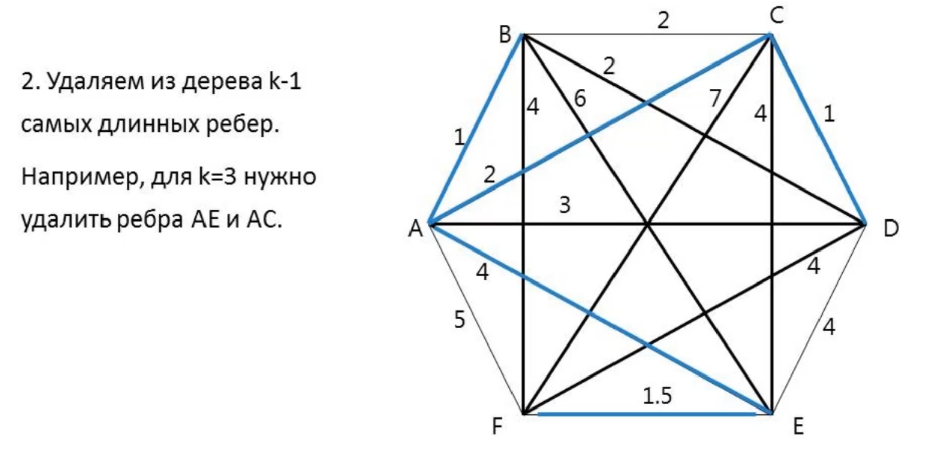

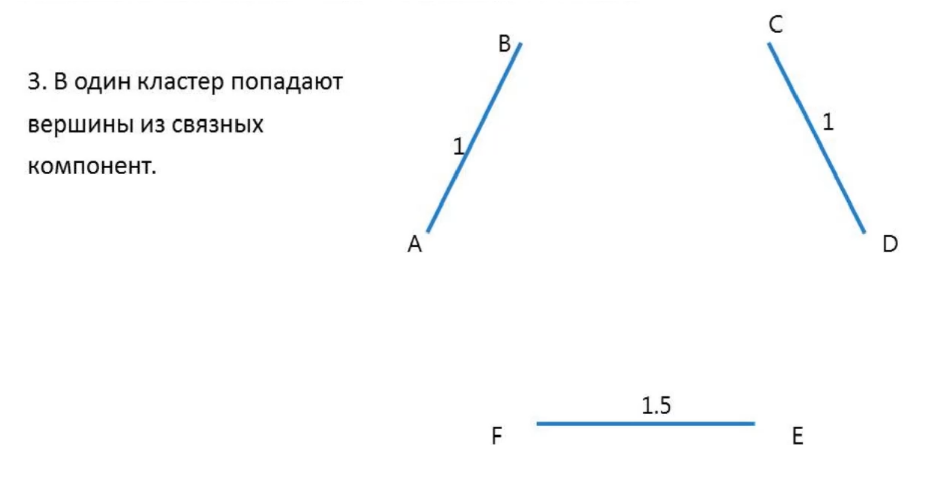

Плюсы такого подхода:

* Наглядность и простота.
* Детерминированность (однозначность).
* Иерархичность.
* Выявление выбросов.
* Работа с любыми расстояниями.

Минусы такого подхода:

* Чувствительность к шуму.
* **Проблема разномасштабных кластеров**.
* Неэффективность на больших данных.
* **Плохая работа со сложной геометрией.**

Поскольку это дерево, то это иерархия. А поскольку удаляется самое длинное ребро, то модель Single-Linkage является одной из реализаций MST алгоритма.

## Spectral clustering

**Суть:** Метод, который рассматривает данные как граф, строит матрицу Лапласа, ищет ее собственные векторы, а затем применяет K-Means к проекции данных на эти векторы.

Плюсы:

* Работа со сложной геометрией. Ему важна связность в графе, а не евклидова близость.

* Устойчивость к разномасштабным кластерам и более глубокий анализ природы данных.

Минусы:

* Вычислительная сложность и неэффективность на больших данных (хотя лучше, чем у MST).

* Чувствительность к параметрам построения графа.

* Нет детерминированности.

* Сложность интерпретации.

В этом случае нам не нужен остовный граф, но и полный тоже. Как правило, строится разреженный граф, чтобы выделить наиболее значимые связи. Существует два популярных способа:

* Граф ε-окрестностей: Соединяем ребром две точки, если расстояние между ними меньше заданного порога ε.

* Граф k ближайших соседей (KNN): Каждая точка соединяется с k самыми близкими к ней соседями.

## Пример работы (Код)

In [31]:
import numpy as np

l = 100
x, y = np.indices((l, l))

center1 = (28, 24)
center2 = (40, 50)
center3 = (67, 58)
center4 = (24, 70)

radius1, radius2, radius3, radius4 = 16, 14, 15, 14

circle1 = (x - center1[0]) ** 2 + (y - center1[1]) ** 2 < radius1**2
circle2 = (x - center2[0]) ** 2 + (y - center2[1]) ** 2 < radius2**2
circle3 = (x - center3[0]) ** 2 + (y - center3[1]) ** 2 < radius3**2
circle4 = (x - center4[0]) ** 2 + (y - center4[1]) ** 2 < radius4**2

In [32]:
img = circle1 + circle2 + circle3 + circle4

# We use a mask that limits to the foreground: the problem that we are
# interested in here is not separating the objects from the background,
# but separating them one from the other.
mask = img.astype(bool)

img = img.astype(float)
img += 1 + 0.2 * np.random.randn(*img.shape)

In [33]:
from sklearn.feature_extraction import image

graph = image.img_to_graph(img, mask=mask)

In [34]:
graph.data = np.exp(-graph.data / graph.data.std())

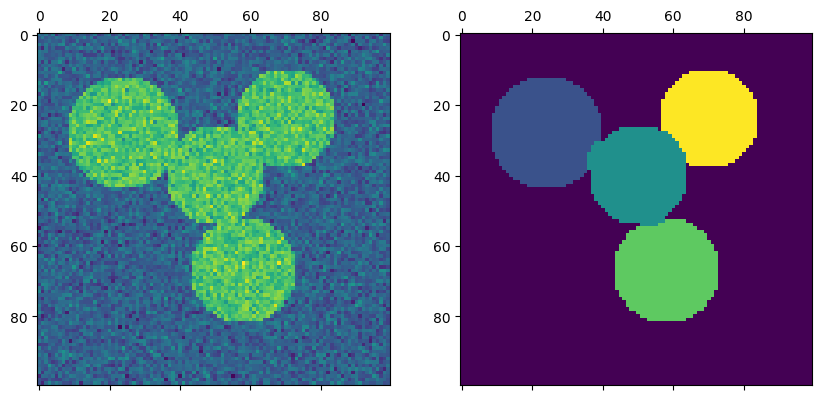

In [36]:
import matplotlib.pyplot as plt

from sklearn.cluster import spectral_clustering # работает именно с графом

labels = spectral_clustering(graph, n_clusters=4, eigen_solver="arpack")
label_im = np.full(mask.shape, -1.0)
label_im[mask] = labels

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
axs[0].matshow(img)
axs[1].matshow(label_im)

plt.show()

За счет того, что алгоритм хорошо работает со сложной геометрией, его можно применять для сегментации изображений. Особенно хорошо работает, когда необходимо малое число кластеров.

Можно попробовать эту модель в примере со сжатием изображения, но это очень затратно по памяти.

# Плотностная кластеризация (DBSCAN)

Более интересным алгоритмом кластеризации является DBSCAN (Density-Based Spatial Clustering of Applications with Noise), который основан на плотности точек в пространстве. Он группирует вместе точки, которые находятся близко друг к другу и отмечает как выбросы точки, которые лежат в областях с низкой плотностью. Помимо того, что DBSCAN может обнаруживать кластеры произвольной формы и выбросы в данных, его главная особенность заключается в самостоятельном определении необходимого количества кластеров, что избавляет от необходимости в их подборе.

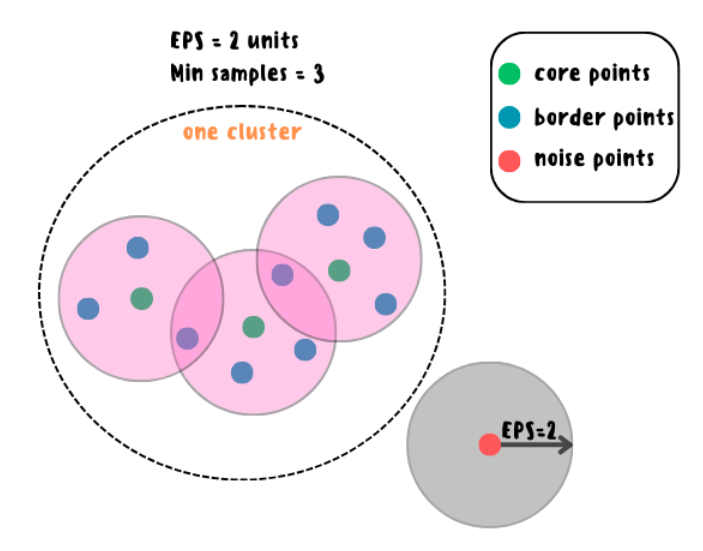


**Вопрос по лекции: Что такое eps, min samples (m) на изображении? Что за зеленые, голубые и красные точки и как они определяются?**

### Алгоритм

**Алгоритм по шагам:**
* Берем случайную точку, которую еще не проверяли.

* Смотрим вокруг нее в радиусе ε.

    * Если соседей много ( ≥ MinPts): поздравляем, мы нашли новый кластер! Помечаем точку как ядровую. Затем мы начинаем «заражать» соседей. Проверяем каждого соседа этой точки: если он тоже ядровый, мы расширяем кластер дальше. Это как цепная реакция или лесной пожар: кластер растет, пока плотность точек высокая.

    * Если соседей мало (< MinPts): помечаем точку как шум. (Важно: позже она может стать граничной, если до нее дотянется растущий кластер с другой стороны, но пока она — шум.)

* Повторяем, пока не посетим все точки.

**DBSCAN**(eps=0.5, *, min_samples=5, metric='euclidean', metric_params=None, algorithm='auto', leaf_size=30, p=None, n_jobs=None)

Параметры:
* eps - радиус окрестности вокруг точки. Точки, находящиеся на расстоянии меньше или равном eps, считаются соседями. Этот параметр определяет, насколько близко точки должны находиться, чтобы считаться частью кластера.
* min_samples - минимальное количество точек, необходимых для формирования плотной области. Точка считается основной точкой, если в ее окрестности eps находится как минимум min_samples точек. Этот параметр определяет минимальный размер кластера.

Дополнительные:
* metric: Метрика, используемая для вычисления расстояния между точками.
* metric_params: Дополнительные ключевые аргументы для функции метрики.
* algorithm: Алгоритм, используемый для вычисления ближайших соседей.
* leaf_size: Размер листа, передаваемый алгоритму BallTree или KDTree.
* p: Параметр степени для метрики Minkowski.
* n_jobs: Количество параллельных заданий для запуска.

## Пример работы (Код)

In [198]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

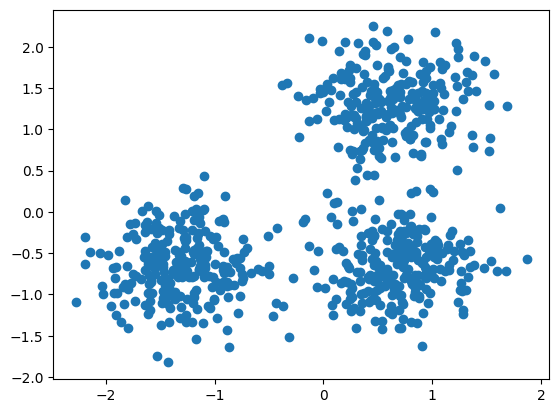

In [199]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [16]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


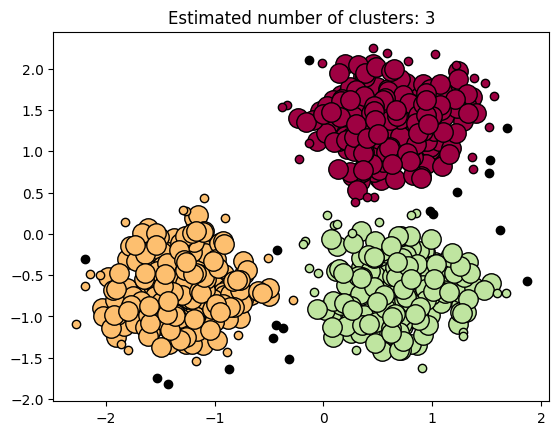

In [17]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

## Задание на дом

**Реализуйте класс DBSCAN_naive, используя алгоритм ниже.**

**Алгоритм по шагам (более подробный):**

1. Инициализируем пустой словарь кластеров, куда будем складывать найденные кластеры, и специальный кластер для шума (например, с индексом 0).

2. Идем по всем точкам по порядку (или случайно), пропуская уже посещенные.

3. Для текущей точки находим всех соседей в радиусе eps (функция region_query).

4. Если соседей меньше, чем min_samples:

    * Помечаем точку как шум (добавляем в кластер шума).

5. Если соседей достаточно (≥ min_samples):

    * Создаем новый кластер (увеличиваем счетчик кластеров).

    * Помечаем текущую точку как ядровую и добавляем её в core_sample_indices_.

    * Запускаем процедуру расширения кластера (expand_cluster) для этой точки и её соседей.

6. Повторяем шаги 2-5, пока не обработаем все точки.

**В процедуре расширения кластера:**

  * Добавляем текущую точку в кластер.

  * Пока есть непроверенные соседи:

  * Берем очередного соседа.

  * Если сосед еще не посещен — посещаем его и находим его соседей.

  * Если у соседа достаточно соседей (≥ min_samples):

      * Помечаем его как ядровую точку (добавляем в core_sample_indices_).

      * Добавляем его соседей в список для проверки (расширяем кластер дальше).

  * Если сосед еще не принадлежит никакому кластеру:

      * Добавляем его в текущий кластер.

      * Если сосед был помечен как шум — убираем его из шума.




In [ ]:
import numpy as np

class DBSCAN_naive:
    def __init__(self, eps, min_samples, distance='euclidean'):
        """
        Параметры:
        eps: float - радиус окрестности
        min_samples: int - минимальное количество соседей для ядровой точки
        distance: str - тип расстояния ('euclidean' или 'manhattan')
        """
        self.eps = eps
        self.min_samples = min_samples
        self.distance = self._get_distance_function(distance)
        self.NOISE = 0  # индекс кластера для шума
        self.clusters = {}  # словарь кластеров
        self.core_sample_indices_ = []  # индексы ядровых точек

    def _get_distance_function(self, distance):
        """Возвращает функцию для вычисления расстояния"""
        # TODO: реализовать выбор функции расстояния
        # Для 'euclidean' вернуть евклидово расстояние
        # Для 'manhattan' вернуть манхэттенское расстояние
        pass

    def fit(self, X):
        """
        X: numpy array формы (n_samples, n_features)

        Запускает алгоритм DBSCAN на данных X.
        Сохраняет результаты в self.clusters.
        Возвращает self.
        """
        self.X = X
        self.visited_points = set()  # множество посещенных индексов
        self.clustered_points = set()  # множество индексов, уже попавших в кластеры
        self.clusters = {self.NOISE: []}  # инициализируем кластер для шума
        self.C = 0  # счетчик кластеров
        self.core_sample_indices_ = []  # сбрасываем список ядровых точек

        # TODO: реализовать основной цикл алгоритма
        # 1. Перебрать все точки по индексам
        # 2. Пропустить уже посещенные точки
        # 3. Для каждой точки найти соседей через _region_query
        # 4. Если соседей мало - добавить в шум
        # 5. Если соседей достаточно - создать новый кластер и запустить _expand_cluster
        pass

    def _region_query(self, point_idx):
        """
        point_idx: индекс точки в X

        Возвращает список индексов всех точек,
        находящихся на расстоянии < eps от точки point_idx.
        """
        # TODO: реализовать поиск соседей
        pass

    def _expand_cluster(self, point_idx, neighbours):
        """
        point_idx: индекс точки, с которой начинаем кластер
        neighbours: список соседей этой точки

        Расширяет кластер, добавляя все достижимые точки.
        Обновляет self.clusters и self.core_sample_indices_.
        """
        # TODO: реализовать расширение кластера
        # 1. Добавить точку point_idx в текущий кластер
        # 2. Пока есть соседи в очереди:
        #    - Взять очередного соседа
        #    - Если он не посещен - посетить и найти его соседей
        #    - Если у него достаточно соседей - добавить его в core_sample_indices_
        #      и расширить очередь его соседями
        #    - Если он еще не в кластере - добавить в текущий кластер
        #      и убрать из шума при необходимости
        pass

    def get_labels(self):
        """
        Возвращает массив меток для каждой точки в X.
        Шум (NOISE) помечается как -1.
        """
        # TODO: реализовать получение меток
        # 1. Создать массив из -1 длиной len(X)
        # 2. Для каждого кластера (кроме шума) проставить его номер соответствующим точкам
        pass

    def get_core_sample_indices(self):
        """
        Возвращает массив индексов ядровых точек.
        """
        # TODO: реализовать получение индексов ядровых точек
        pass

### Тестирование работы модели

In [201]:
db = DBSCAN_naive(eps=0.3, min_samples=10).fit(X)
labels = db.get_labels()

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


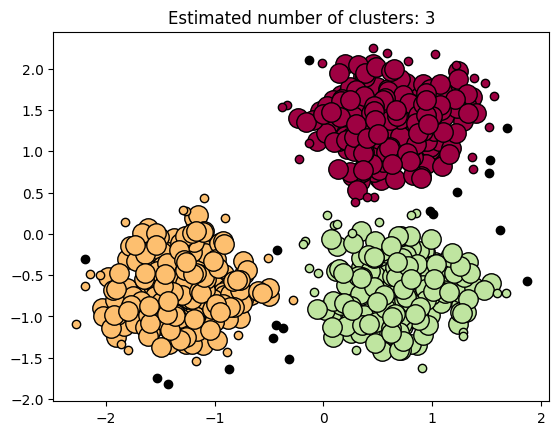

In [36]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.get_core_sample_indices()] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

## Выводы по DBSCAN

Плюсы DBSCAN:
* Не нужно знать число кластеров.

* Кластеры любой формы.

* Устойчивость к выбросам (шуму).


Минусы DBSCAN:

* Проблема разной плотности.

* Проклятие размерности.

* Сложность выбора параметров.

Однако выбор оптимальных eps и min_samples на практике может оказаться довольно трудной задачей, поскольку данные параметры существенно влияют на результаты кластеризации.

Как подбирать параметры на практике?

* **min_samples**. Хорошее эмпирическое правило — брать min_samples  размерность данных + 1. Если у вас 2D-данные (как в примере), берите минимум 3 или 4. Если данные очень шумные, увеличивайте это число.

* **eps**. Тут ситуация сложнее. Слишком маленький eps — и у вас будет куча шума и миллион маленьких кластеров. Слишком большой eps — и все сольется в один гигантский ком. Обычно начинают с малого и постепенно увеличивают, смотря на процент точек, помеченных как шум.

Частично данную проблему можно решить с использованием HDBSCAN — модификации DBSCAN, которая автоматически находит подходящее значение eps для каждого кластера, используя иерархический подход, что позволяет определять кластеры разной плотности и повысить устойчивость к выбросам.

# Использование кластеризации для поиска выбросов

## Пример

In [117]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Генерация данных
X, y = make_classification(n_samples=500, n_features=6, n_informative=5,
                          n_redundant=1, n_clusters_per_class=1,
                          flip_y=0.05, random_state=42)

# Добавляем искусственные выбросы (5% от данных)
np.random.seed(42)
outliers = np.random.uniform(low=-25, high=25, size=(25, 6))
X = np.vstack([X, outliers])
y = np.append(y, [0]*10 + [1]*15)  # добавляем метки для выбросов

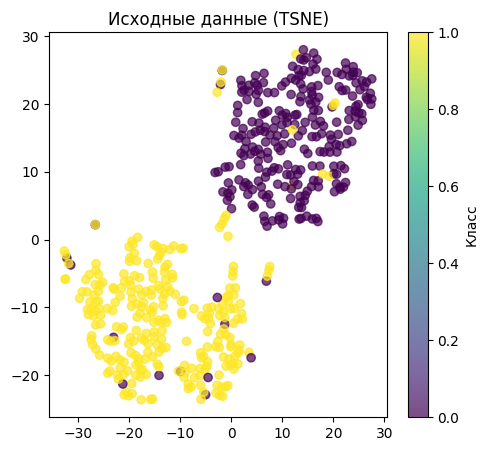

In [118]:
# 2. Визуализация с TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.title('Исходные данные (TSNE)')
plt.colorbar(label='Класс')


In [127]:
# 3. Поиск выбросов DBSCAN
dbscan = DBSCAN(eps=3, min_samples=3)
clusters = dbscan.fit_predict(X)
outliers_mask = clusters == -1

print(f"Найдено выбросов: {np.sum(outliers_mask)}")

Найдено выбросов: 26


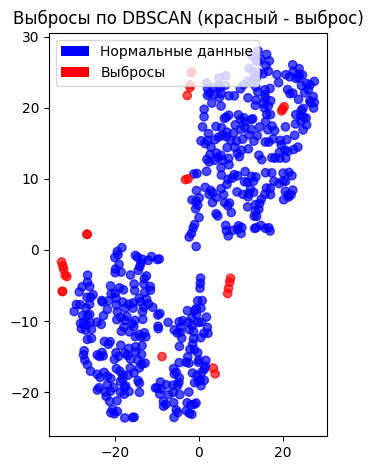

In [128]:
# 4. Визуализация выбросов
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                     c=['red' if o else 'blue' for o in outliers_mask],
                     alpha=0.7)
plt.title('Выбросы по DBSCAN (красный - выброс)')

# Создаем легенду вручную
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='Нормальные данные'),
                   Patch(facecolor='red', label='Выбросы')]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

In [129]:
# 5. Сравнение моделей
# Данные без выбросов
X_clean = X[~outliers_mask]
y_clean = y[~outliers_mask]

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.3, random_state=42)

# Модель на всех данных
rf_all = RandomForestClassifier(random_state=42)
rf_all.fit(X_train, y_train)
y_pred_all = rf_all.predict(X_test)

# Модель на данных без выбросов
rf_clean = RandomForestClassifier(random_state=42)
rf_clean.fit(X_train_clean, y_train_clean)
y_pred_clean = rf_clean.predict(X_test_clean)

# 6. Результаты
print("\n" + "="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*50)
print(f"Модель на всех данных:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_all):.3f}")
print(f"  F1-score: {f1_score(y_test, y_pred_all):.3f}")

print(f"\nМодель после удаления выбросов:")
print(f"  Accuracy: {accuracy_score(y_test_clean, y_pred_clean):.3f}")
print(f"  F1-score: {f1_score(y_test_clean, y_pred_clean):.3f}")

# 7. Сводная таблица
results = pd.DataFrame({
    'Модель': ['Все данные', 'После удаления выбросов'],
    'Accuracy': [accuracy_score(y_test, y_pred_all),
                 accuracy_score(y_test_clean, y_pred_clean)],
    'F1-score': [f1_score(y_test, y_pred_all),
                 f1_score(y_test_clean, y_pred_clean)]
})

print("\n" + "="*50)
print("СВОДНАЯ ТАБЛИЦА")
print("="*50)
print(results.to_string(index=False))


СРАВНЕНИЕ МОДЕЛЕЙ
Модель на всех данных:
  Accuracy: 0.924
  F1-score: 0.924

Модель после удаления выбросов:
  Accuracy: 0.953
  F1-score: 0.952

СВОДНАЯ ТАБЛИЦА
                 Модель  Accuracy  F1-score
             Все данные  0.924051  0.924051
После удаления выбросов  0.953333  0.952381


## Задание

**Реализуйте класс DataPreprocessor для автоматической предобработки данных с возможностью использования моделей кластеризации DBSCAN, HDBSCAN для удаления выбросов.**

Класс объединяет масштабирование данных, поиск параметров кластеризации и удаление аномалий в единый пайплайн.

То есть вам необходимо:
1. Реализовать функцию fit_transform: провести масштабирование данных, подобрать параметры (для DBSCAN), удалить выбросы.
2. Реализовать функцию find_best_dbscan_params, которая ищет лучшие параметры для модели. На вход ей подается словарь с возможными значениями параметров eps, min_samples - среди них нужно найти наилучшую комбинацию (с помощью цикла и метода product). Оценка качества с помощью модели RandomForestClassifier и метода cross_val_score.
3. Реализовать функцию remove_outliers для удаления выбросов на основе выбранной модели.

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from itertools import product

class DataPreprocessor:
    def __init__(self, scaler=StandardScaler(), clusterer=DBSCAN()):
        """
        Параметры:
        scaler: объект для масштабирования данных (должен иметь методы fit_transform)
        clusterer: объект для кластеризации (должен иметь метод fit_predict)
        """
        # TODO: инициализировать атрибуты класса
        # self.scaler = ...
        # self.clusterer = ...
        # self.best_params = ...  # лучшие параметры (изначально None)
        # self.best_score = ...   # лучшая оценка (изначально -inf)
        pass

    def scale_data(self, X):
        """
        X: numpy array или pandas DataFrame

        Масштабирует данные с помощью self.scaler.
        Возвращает масштабированные данные.
        """
        # TODO: применить масштабировщик к данным
        pass

    def find_best_dbscan_params(self, X, y, param_grid):
        """
        X: признаки (будут масштабированы внутри метода)
        y: целевая переменная
        param_grid: словарь с сеткой параметров, например:
            {'eps': [0.3, 0.5, 0.7], 'min_samples': [3, 5, 10]}

        Ищет лучшие параметры DBSCAN, максимизирующие качество RandomForest
        на данных без выбросов.

        Возвращает словарь с лучшими параметрами.
        Обновляет self.best_params и self.best_score.
        """
        # TODO: реализовать поиск параметров
        # 1. Масштабировать данные
        # 2. Перебрать все комбинации параметров из param_grid
        # 3. Для каждой комбинации:
        #    - Применить DBSCAN к масштабированным данным
        #    - Создать маску clean_mask (точки не равные -1)
        #    - Проверить, что после удаления выбросов осталось >= 50% данных
        #    - Обучить RandomForest на чистых данных и оценить через cross_val_score
        #    - Если оценка лучше self.best_score - обновить лучшие параметры и оценку
        # 4. Вывести лучшие параметры и оценку
        # 5. Вернуть лучшие параметры
        pass

    def remove_outliers(self, X, y=None, params=None):
        """
        X: признаки
        y: целевая переменная (опционально)
        params: параметры DBSCAN (опционально)

        Удаляет выбросы (точки, помеченные DBSCAN как -1).

        Если params передан - применяет clusterer с этими параметрами.
        Иначе использует текущие параметры clusterer.

        Возвращает:
        - если y передан: (X_clean, y_clean, clean_mask)
        - иначе: (X_clean, clean_mask)
        """
        # TODO: реализовать удаление выбросов
        # 1. Масштабировать данные
        # 2. Если params передан - обновить параметры clusterer
        # 3. Применить clusterer.fit_predict к масштабированным данным
        # 4. Создать маску clean_mask (точки с меткой != -1)
        # 5. Вернуть результаты в зависимости от наличия y
        pass

    def fit_transform(self, X, y=None, param_grid=None):
        """
        X: признаки
        y: целевая переменная (опционально)
        param_grid: сетка параметров для поиска (опционально)

        Полный пайплайн обработки:
        - Если передан param_grid и y: ищет лучшие параметры и применяет их
        - Иначе: применяет удаление выбросов с текущими параметрами

        Возвращает результат remove_outliers.
        """
        # TODO: реализовать полный пайплайн
        # 1. Если передан param_grid и y:
        #    - Найти лучшие параметры
        #    - Удалить выбросы с лучшими параметрами
        # 2. Иначе:
        #    - Удалить выбросы с текущими параметрами
        pass

### Тестирование работы

In [37]:
pip install ucimlrepo

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from ucimlrepo import fetch_ucirepo

In [139]:
# Загрузка данных
glass_identification = fetch_ucirepo(id=42)
X = glass_identification.data.features
y = glass_identification.data.targets

X.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0


In [168]:
# Создание препроцессора
preprocessor = DataPreprocessor(
    scaler=StandardScaler(),
    clusterer=DBSCAN()
)

# Поиск параметров и обработка
param_grid = {
    'eps': [0.7, 1.0, 1.3, 1.5, 1.7, 2.0],
    'min_samples': [3, 5, 7]
}

X_clean, y_clean, mask = preprocessor.fit_transform(X, y, param_grid=param_grid)
print(f"\nDBSCAN удалил: {np.sum(~mask)} образцов")

Лучшие параметры: {'eps': 1.0, 'min_samples': 5}, score: 0.8027

DBSCAN удалил: 67 образцов


In [170]:
# Для HDBSCAN (параметры другие)
preprocessor_hd = DataPreprocessor(
    scaler=MinMaxScaler(),
    clusterer=HDBSCAN(min_cluster_size=5)
)
X_clean, y_clean, mask = preprocessor_hd.remove_outliers(X, y)
print(f"\nHDBSCAN удалил: {np.sum(~mask)} образцов")


HDBSCAN удалил: 33 образцов


In [171]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.3, random_state=42, stratify=y_clean)

# Модели
rf1 = RandomForestClassifier(random_state=42)
rf2 = RandomForestClassifier(random_state=42)

# Обучение
rf1.fit(X_train, y_train)
rf2.fit(X_train_clean, y_train_clean)

# Предсказания
y_pred1 = rf1.predict(X_test)
y_pred2 = rf2.predict(X_test_clean)

# Результаты
results = pd.DataFrame({
    'Модель': ['Исходные данные', 'После удаления выбросов'],
    'Accuracy': [accuracy_score(y_test, y_pred1), accuracy_score(y_test_clean, y_pred2)],
    'F1-score': [f1_score(y_test, y_pred1, average='weighted'),
                 f1_score(y_test_clean, y_pred2, average='weighted')],
    'Размер трейна': [len(X_train), len(X_train_clean)],
    'Выбросы удалено': [0, np.sum(~mask)]
})

print("\nСРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)
print(results.to_string(index=False))


СРАВНЕНИЕ МОДЕЛЕЙ
                 Модель  Accuracy  F1-score  Размер трейна  Выбросы удалено
        Исходные данные  0.830769  0.825306            149                0
После удаления выбросов  0.854545  0.848328            126               33
